# Notebook 2 — The Vibe Coding Lab — Completed
Source: DigiHaz Module 7 Topic 4 `02_vibe_coding_lab.ipynb`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Setup complete')


Setup complete


## Four candidate soil-moisture functions


In [2]:
def A(raw): return (raw-3300)/(1200-3300)*100
def B(raw): return np.clip(100*(3300-raw)/(3300-1200),0,100)
def C(raw):
    if not isinstance(raw,(int,float)): raise TypeError('numeric input required')
    if raw>3300*1.2 or raw<1200*0.5: return None
    return max(0.0,min(100.0,float(100*(3300-raw)/(3300-1200))))
def D(raw):
    p=100*(3300-raw)/(3300-1200)
    corrected=p+0.005*p**2-0.0001*p**3
    return max(0.0,min(100.0,corrected))
vals=[3300,1200,2250,4000,800,2500]
for name,f in [('A',A),('B',B),('C',C),('D',D)]: print(name,[f(v) for v in vals])


A [-0.0, 100.0, 50.0, -33.33333333333333, 119.04761904761905, 38.095238095238095]
B [np.float64(0.0), np.float64(100.0), np.float64(50.0), np.float64(0.0), np.float64(100.0), np.float64(38.095238095238095)]
C [0.0, 100.0, 50.0, None, 100.0, 38.095238095238095]
D [0.0, 50.0, 50.0, 0.0, 21.19101608897526, 39.822913292301045]


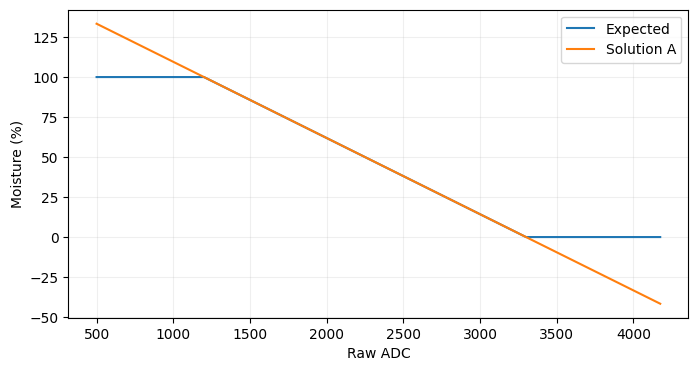

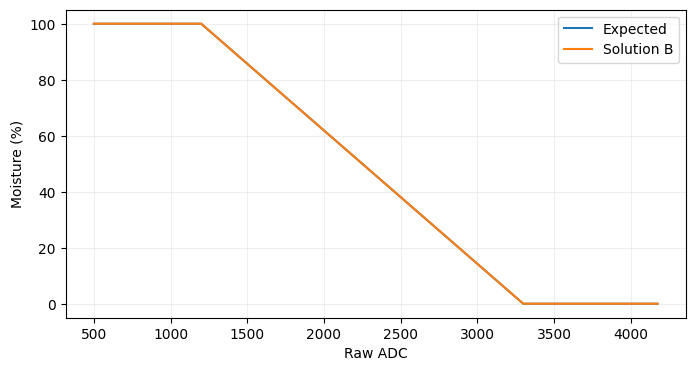

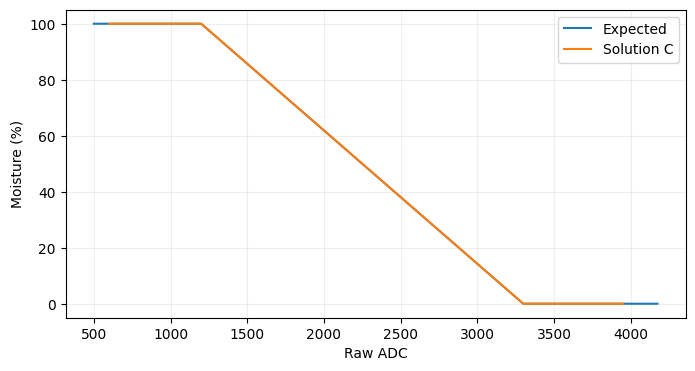

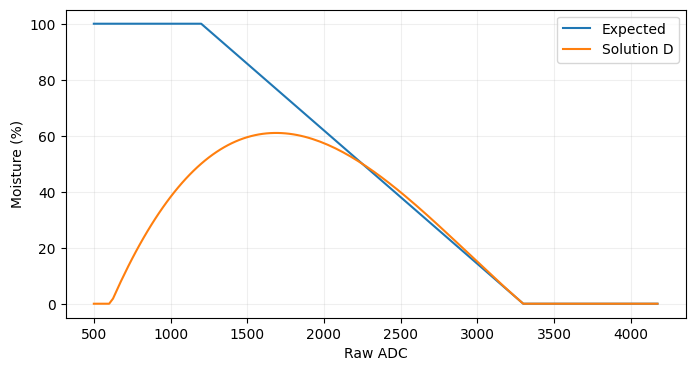

In [3]:
raw=np.arange(500,4200,25)
expected=[B(r) for r in raw]
for name,f in [('A',A),('B',B),('C',C),('D',D)]:
    y=[np.nan if (v:=f(int(r))) is None else v for r in raw]
    plt.figure(figsize=(8,4)); plt.plot(raw,expected,label='Expected'); plt.plot(raw,y,label='Solution '+name); plt.xlabel('Raw ADC'); plt.ylabel('Moisture (%)'); plt.legend(); plt.grid(alpha=.2); plt.show()


## Diagnosis — Completed
- **A: Partial; plausible nonsense.** Correct inside the calibration interval, but violates the required 0–100 output range: 4000→-33.33%, 800→119.05%. A downstream alert may accept physically impossible values.
- **B: Correct for the stated prompt; no failure mode.** It performs the requested linear mapping and clamping. A separate diagnostic flag would still be useful because clamping can hide calibration faults.
- **C: Partial; plausible nonsense.** It invents unsupported “sensor disconnected” cutoffs and may return `None`, violating the requested float return type. The heuristic is also asymmetric.
- **D: No; plausible nonsense.** It invents an unvalidated polynomial; the wet calibration endpoint 1200 maps to only **50%**, which could suppress a genuine saturation warning.


## Prompt used for the ESP32/MPU6050 task
Write MicroPython code for an ESP32 using an MPU6050 over I²C (SDA GPIO21, SCL GPIO22, 400 kHz, default address 0x68). Wake it through register 0x6B, read ±2 g acceleration at 16384 LSB/g, compute tilt from vertical in degrees with `atan2(sqrt(ax²+ay²), az)`, and publish every 5 seconds to MQTT topic `digihaz/yueqimin/tilt`. Load Wi‑Fi/MQTT secrets from `secrets.py`, use TLS on port 8883, and include reconnect/error handling. Do not hard-code passwords. Explain assumptions.


## Representative LLM response
```python
from machine import Pin, I2C
from umqtt.simple import MQTTClient
import network, time, math, json, ubinascii, machine, secrets
MPU_ADDR=0x68; PWR_MGMT_1=0x6B; ACCEL_XOUT_H=0x3B; SCALE=16384.0
TOPIC=b'digihaz/yueqimin/tilt'
i2c=I2C(0,scl=Pin(22),sda=Pin(21),freq=400000)
i2c.writeto_mem(MPU_ADDR,PWR_MGMT_1,b'\x00')

def i16(b,i):
    v=(b[i]<<8)|b[i+1]
    return v-65536 if v&0x8000 else v

def read_tilt():
    b=i2c.readfrom_mem(MPU_ADDR,ACCEL_XOUT_H,6)
    ax,ay,az=[i16(b,j)/SCALE for j in (0,2,4)]
    return math.degrees(math.atan2(math.sqrt(ax*ax+ay*ay),az))
# Wi-Fi/MQTT connection uses values imported from secrets.py.
# MQTTClient(..., port=8883, ssl=True); reconnect on OSError; publish every 5 s.
```

**Assumption:** exact TLS certificate-validation behavior must be verified on the specific MicroPython firmware/`umqtt.simple` build before field deployment.


## Code review — Completed
1. **Pins:** SDA=21/SCL=22 are valid standard ESP32 I²C pins, but wiring must still be verified.
2. **Address:** 0x68 is the normal default MPU6050 address.
3. **Tilt formula:** `atan2(sqrt(ax²+ay²), az)` is appropriate for angle from vertical and the result is converted to degrees.
4. **Credentials/security:** secrets are externalized and TLS is requested. The exact CA/certificate behavior must be tested on the target firmware.
5. **Error handling:** reconnect-on-`OSError` is a useful baseline; production firmware should add exponential backoff, a watchdog, local buffering, and a heartbeat/offline monitor.


## Final reflection
I would trust an LLM most for low-risk scaffolding: parsing, JSON/CSV formatting, plotting, repetitive MQTT boilerplate, documentation, and test-data generation. Those parts are easy to inspect and failures are usually visible. I would always review sensor calibration, pin assignments, physical-unit conversions, alert thresholds, power management, and security because those elements affect measurement validity and public-safety decisions.

The soil-moisture examples make the risk concrete. Solution D sounds sophisticated because it claims an “empirical correction,” yet the invented polynomial maps the calibrated wet endpoint to only 50%. That is exactly the kind of plausible output that can survive a superficial review. Solution A shows a different issue: correct algebra inside a calibration interval is still unsafe if real ADC readings can fall outside that interval.

My view of AI-assisted coding changed from “AI writes the code” to “AI accelerates a testable engineering loop.” I would prompt, generate, run reference cases, inspect failure modes, and only then integrate. For safety-relevant code, the human reviewer must own the assumptions.

If I published research using AI-assisted sensor firmware, I would disclose the model/tool used, where it entered the workflow, the final firmware commit, hardware/library versions, calibration procedure, validation tests, error-handling and security checks, and which components were independently verified. I would archive the final code and tests so readers can distinguish an LLM-assisted implementation choice from a physically validated measurement or alerting rule.
